# Investigate alignment failures

15 of 217 patients were **correctly rejected** by `scripts/build_aligned_dataset.py`'s geometric sanity checks (13 "warped corners fall outside the raw photo bounds," 2 "warped area ratio outside sanity bounds") rather than silently given a wrong alignment. This notebook does **not** attempt any alignment or homography -- it's purely a visual side-by-side of each failed patient's full raw photo and original palpebral crop, at native (un-padded, un-resized) resolution, straight from `archive.zip`, so the reason for the failure (severe artifacts, extreme rotation, an unusually large scale difference, etc.) can be judged by eye.

For each of the 15 patients this shows:
- The full raw high-resolution eye photo.
- The original palpebral crop.
- Both images' true native pixel dimensions, and the specific reason `build_aligned_dataset.py` rejected this patient.

In [1]:
import io
import sys
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps

# Assumes the notebook is run from within notebooks/ (Jupyter's default cwd
# when opened from that folder).
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from phase0_prepare_dataset import ZIP_PATH, find_source_files, sanitize_png_bytes  # noqa: E402

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPLITS_CSV = PROCESSED_DIR / "dataset_splits.csv"
ALIGNMENT_LOG_CSV = PROCESSED_DIR / "aligned_raw" / "alignment_log.csv"

print("PROJECT_ROOT:      ", PROJECT_ROOT)
print("ZIP_PATH exists:   ", ZIP_PATH.exists())
print("SPLITS_CSV exists: ", SPLITS_CSV.exists())
print("ALIGNMENT_LOG_CSV exists:", ALIGNMENT_LOG_CSV.exists())

PROJECT_ROOT:       D:\khaje\EYES-DEFY-ANEMIA
ZIP_PATH exists:    True
SPLITS_CSV exists:  True
ALIGNMENT_LOG_CSV exists: True


## 1. Isolate the 15 failed patients

In [2]:
alignment_log = pd.read_csv(ALIGNMENT_LOG_CSV)
splits_df = pd.read_csv(SPLITS_CSV)

failed_log = alignment_log[alignment_log["status"] != "ok"].copy()
failed_ids = failed_log["patient_id"].tolist()

print(f"Failed patients: {len(failed_ids)} / {len(alignment_log)}\n")
print(failed_log[["patient_id", "status"]].to_string(index=False))

print("\nFailure reason breakdown:")
print(failed_log["status"].value_counts())

# Pull country/number for each failed patient (needed to locate them inside archive.zip)
failed_rows = splits_df[splits_df["patient_id"].isin(failed_ids)].merge(
    failed_log[["patient_id", "status"]], on="patient_id"
)
assert len(failed_rows) == len(failed_ids), "not every failed patient_id was found in dataset_splits.csv"

Failed patients: 15 / 217

patient_id                                                        status
 India_002 failed: warped crop corners fall outside the raw photo bounds
 India_003 failed: warped crop corners fall outside the raw photo bounds
 India_015 failed: warped crop corners fall outside the raw photo bounds
 India_019 failed: warped crop corners fall outside the raw photo bounds
 India_044 failed: warped crop corners fall outside the raw photo bounds
 India_050 failed: warped crop corners fall outside the raw photo bounds
 India_060         failed: warped area ratio 0.022 outside sanity bounds
 India_077 failed: warped crop corners fall outside the raw photo bounds
 India_080         failed: warped area ratio 0.000 outside sanity bounds
 India_082 failed: warped crop corners fall outside the raw photo bounds
 India_086 failed: warped crop corners fall outside the raw photo bounds
 India_092 failed: warped crop corners fall outside the raw photo bounds
 India_095 failed: warpe

## 2. Side-by-side: full raw photo vs. original crop (native resolution, no alignment attempted)

Both images are read directly from `archive.zip` at their true native pixel size (the same bytes `build_aligned_dataset.py` reads, before any pad/resize) -- only downscaled for *display* here, not for analysis. Dimensions are printed exactly.

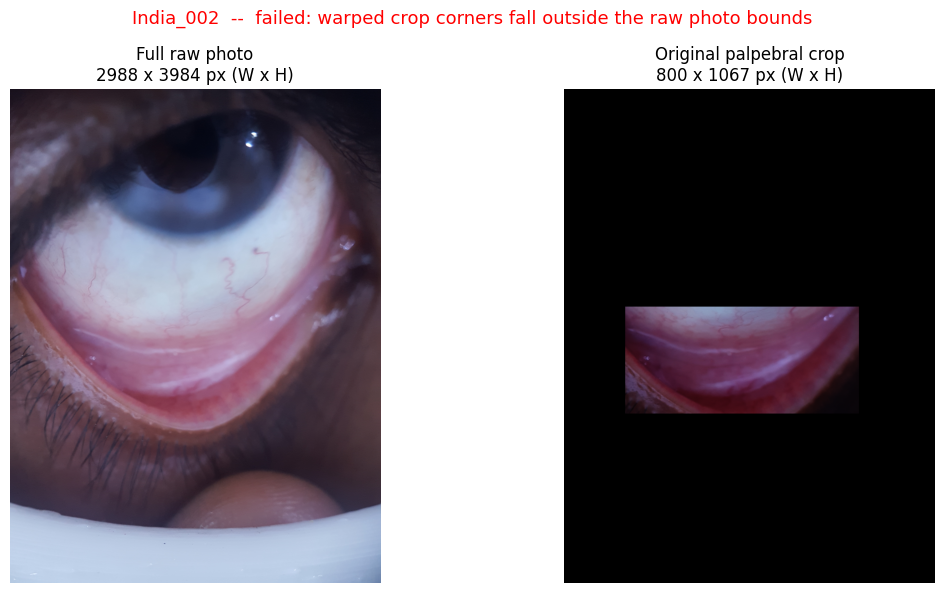

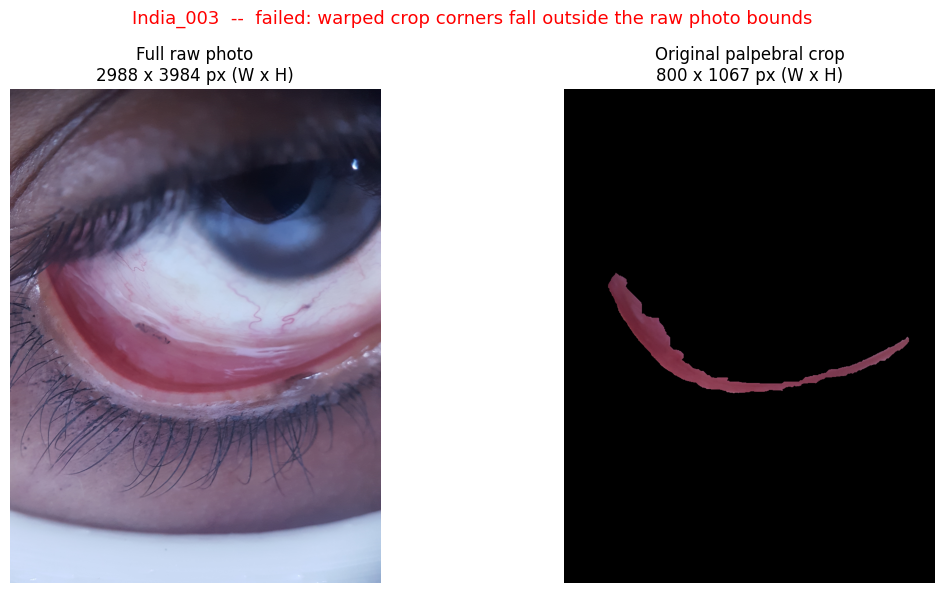

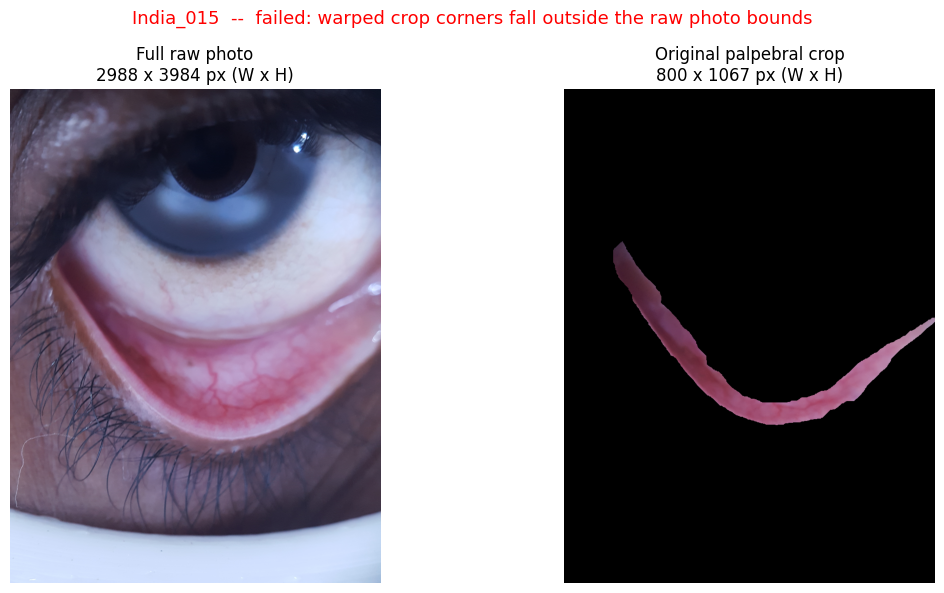

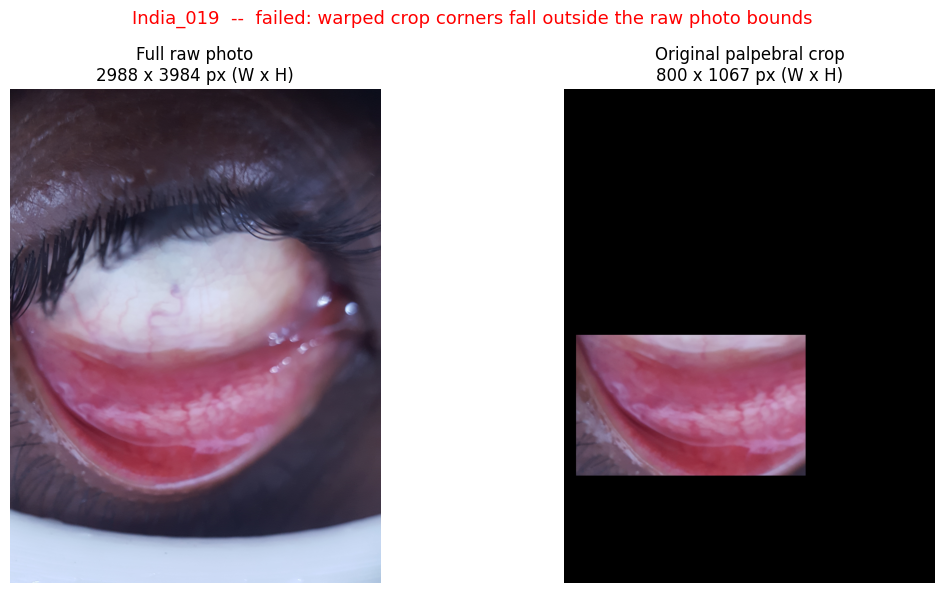

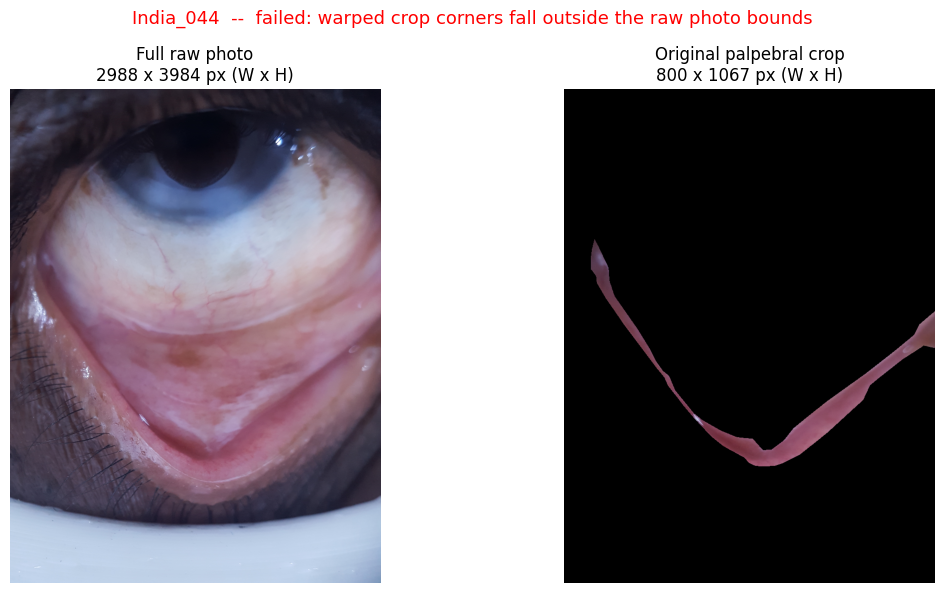

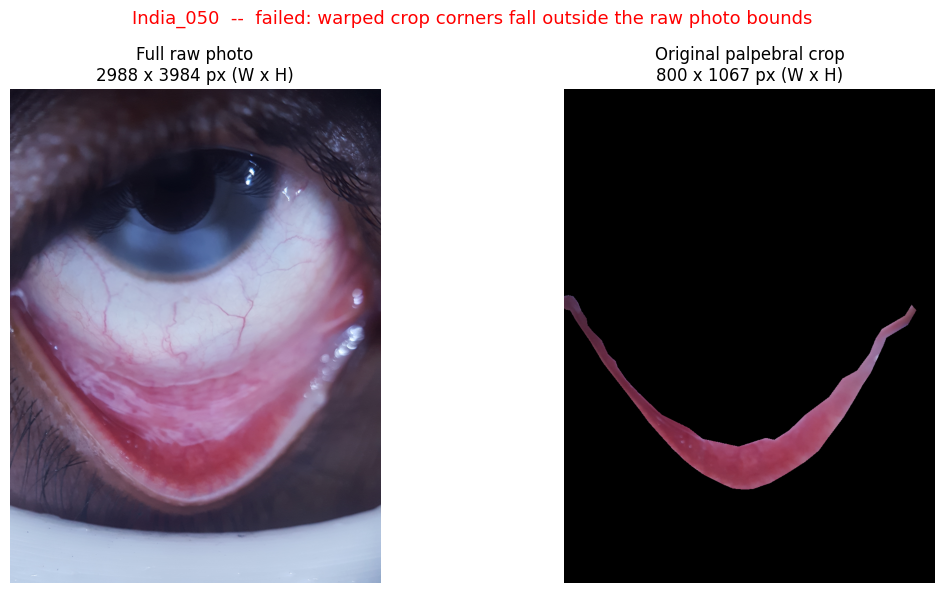

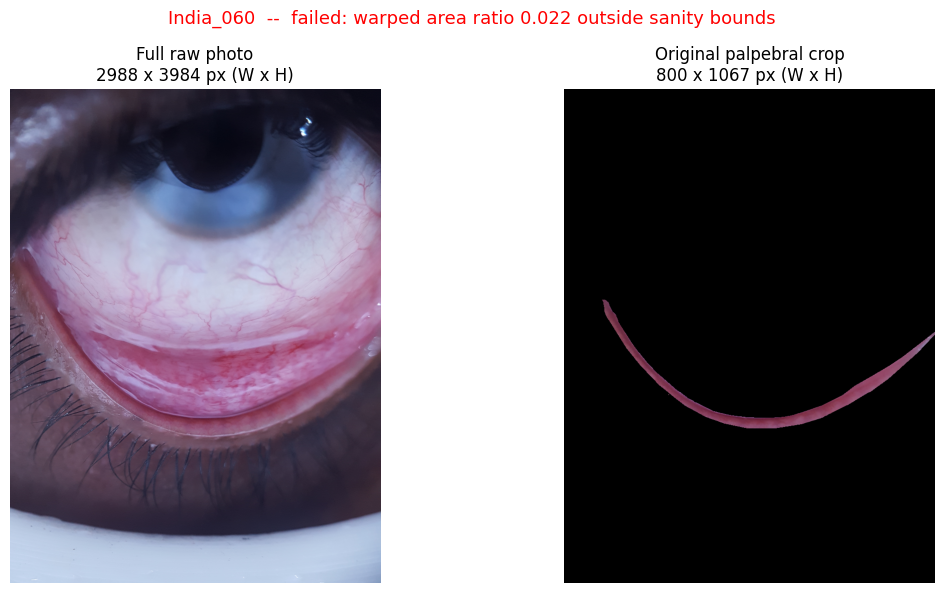

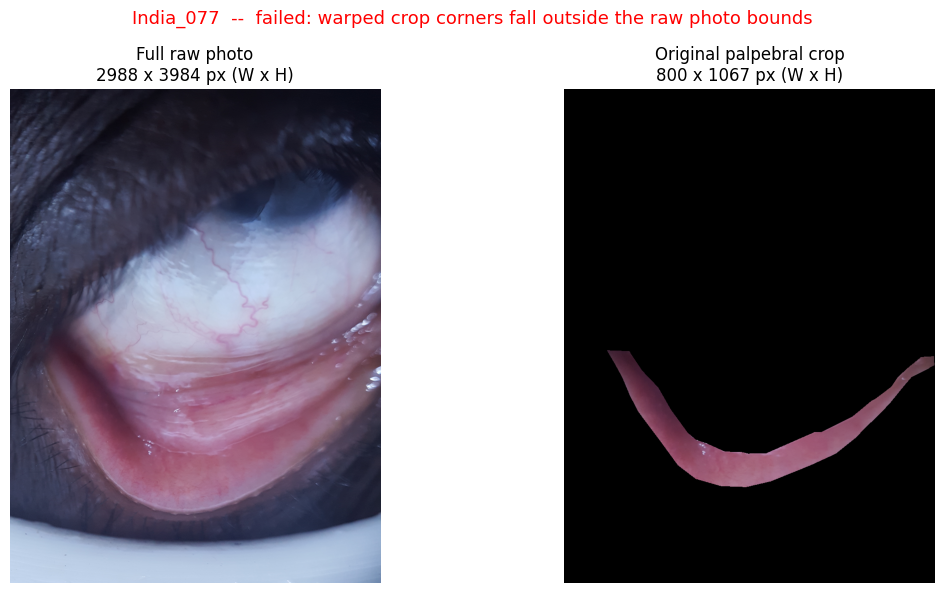

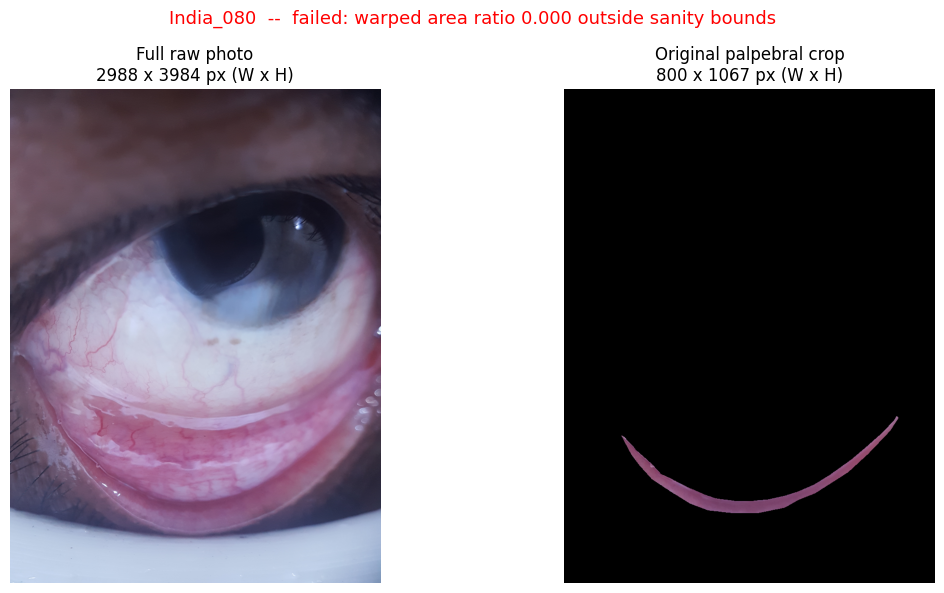

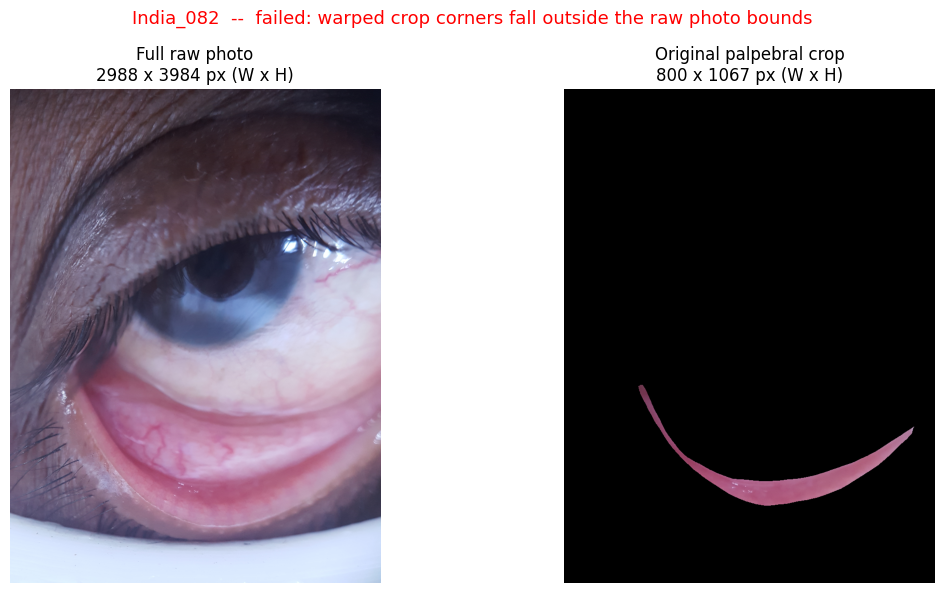

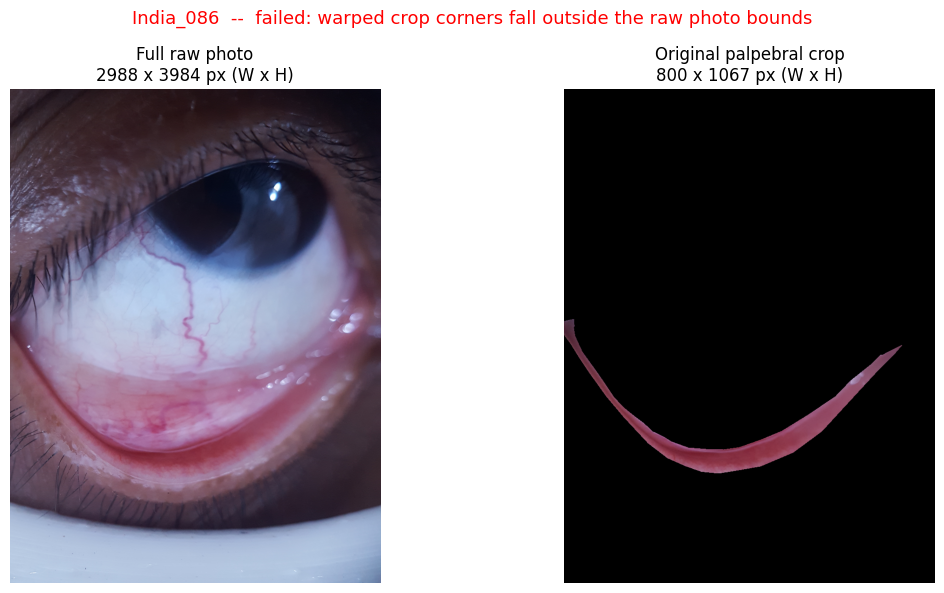

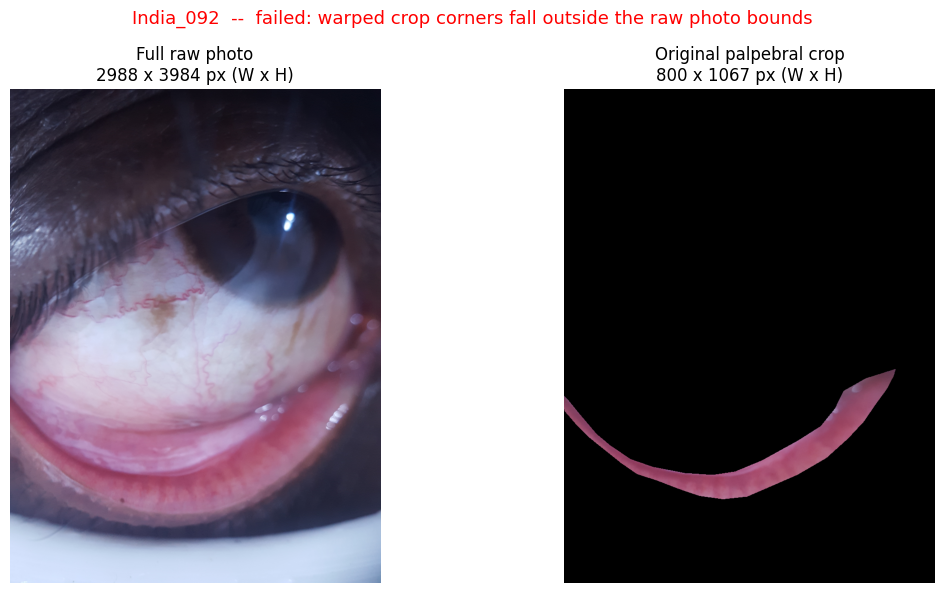

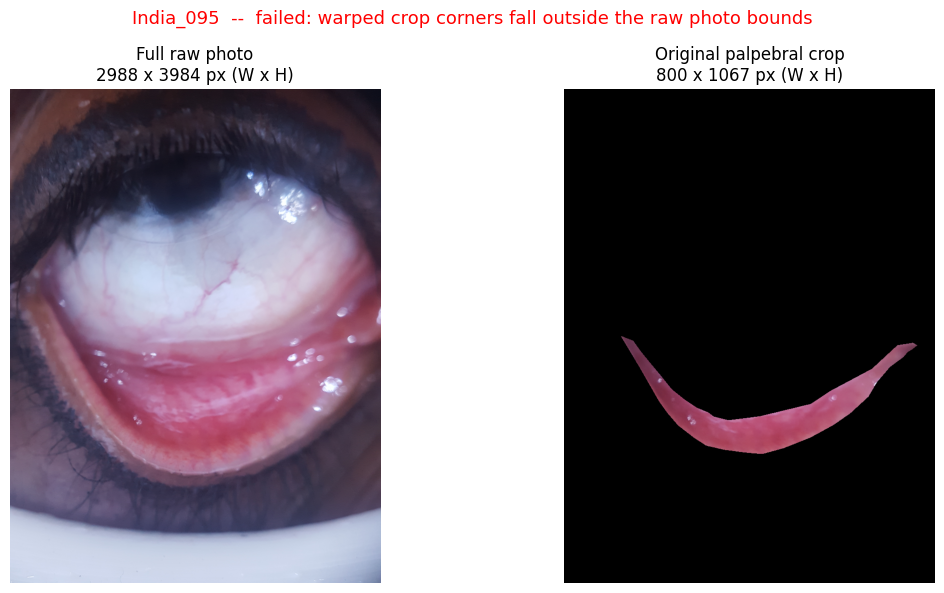

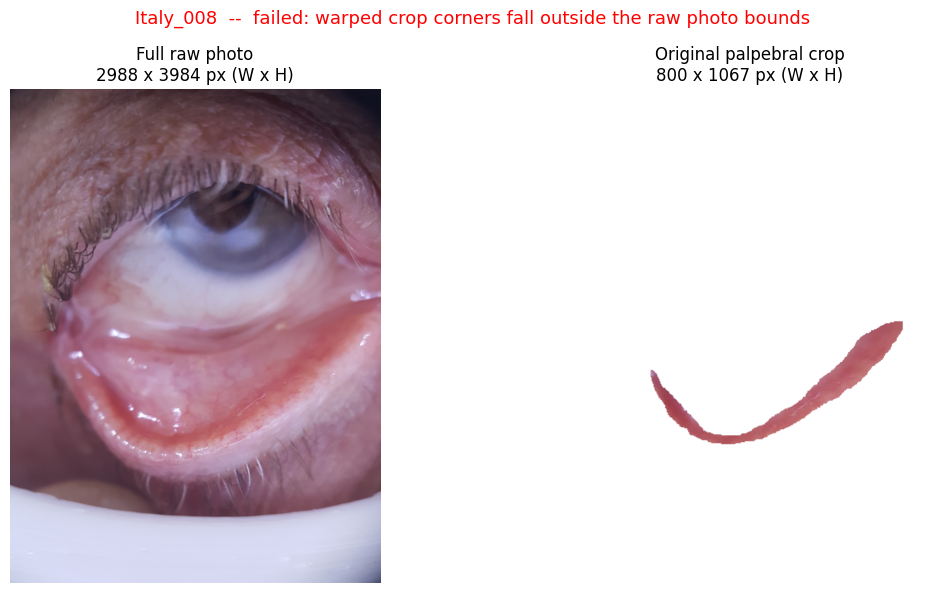

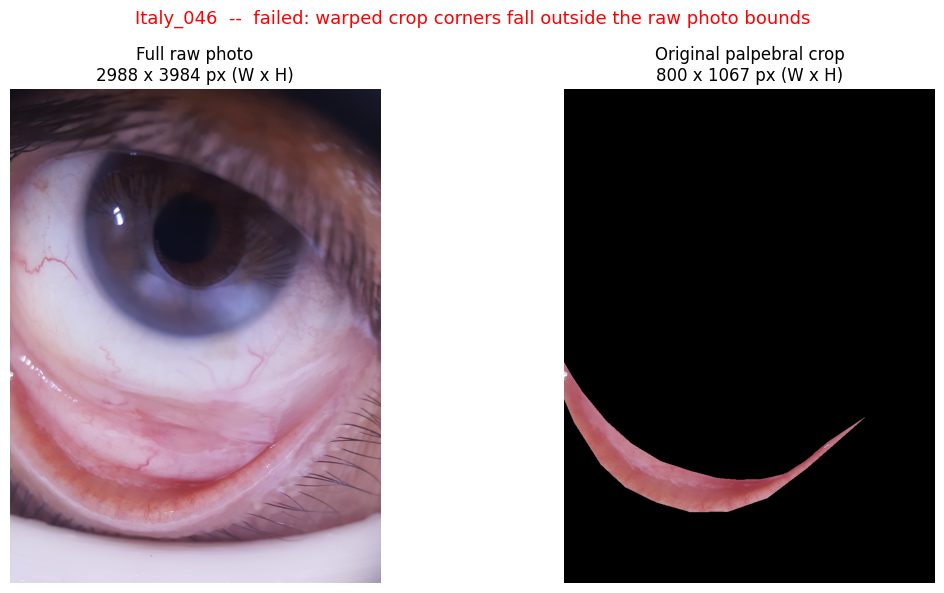

In [3]:
def load_native_raw_and_crop(zf: zipfile.ZipFile, country: str, number: int):
    """Reads the ORIGINAL, un-padded, native-resolution raw photo and
    palpebral crop straight from archive.zip -- no alignment, no pad/resize.
    Mirrors build_aligned_dataset.py's own loading exactly, so what's shown
    here is precisely what that script saw before rejecting the patient."""
    jpg_name, png_name = find_source_files(zf, country, number)

    raw_img = Image.open(io.BytesIO(zf.read(jpg_name)))
    raw_img = ImageOps.exif_transpose(raw_img).convert("RGB")

    crop_img = Image.open(io.BytesIO(sanitize_png_bytes(zf.read(png_name)))).convert("RGB")

    return np.array(raw_img), np.array(crop_img)


with zipfile.ZipFile(ZIP_PATH) as zf:
    for _, row in failed_rows.iterrows():
        patient_id, country, number, status = row["patient_id"], row["country"], int(row["number"]), row["status"]

        raw_array, crop_array = load_native_raw_and_crop(zf, country, number)

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle(f"{patient_id}  --  {status}", fontsize=13, color="red")

        axes[0].imshow(raw_array)
        axes[0].set_title(f"Full raw photo\n{raw_array.shape[1]} x {raw_array.shape[0]} px (W x H)")
        axes[0].axis("off")

        axes[1].imshow(crop_array)
        axes[1].set_title(f"Original palpebral crop\n{crop_array.shape[1]} x {crop_array.shape[0]} px (W x H)")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()